# Pre-processing Web PTA

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
cd /content/drive/MyDrive/PPW

/content/drive/MyDrive/PPW


# Instalasi Library Sastrawi di Google Colab
Perintah !pip install Sastrawi digunakan untuk menginstal library Sastrawi, yang berfungsi dalam proses pemrosesan bahasa alami (Natural Language Processing / NLP) khusus untuk Bahasa Indonesia.

In [11]:
!pip install Sastrawi

# Import Library & Load Data
Kode ini digunakan untuk memproses data CSV dari file manajemen.csv, dengan cara mengambil hanya kolom abstrak_indo, lalu menghapus baris yang kosong (NaN)

In [12]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/PPW/manajemen.csv'
df = pd.read_csv(file_path)

# Hanya ambil kolom abstrak_indo dan buang NaN
abstrak_df = df[['abstrak_indo']].dropna().reset_index(drop=True)

# Simpan ke CSV
abstrak_df.to_csv('/content/drive/MyDrive/PPW/manajemen_abstrak.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
abstrak_df.head()


Data berhasil disimpan ke CSV!



,abstrak_indo
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel..."
1,Tujuan penelitian ini adalah untuk mengetahui ...
2,Aplikasi nyata pemanfaatan teknologi informasi...
3,Abstrak\r\nPenelitian ini menggunakan metode k...
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi..."


Kode ini digunakan untuk menampilkan jumlah data sebelum dan sesudah penghapusan nilai kosong (NaN) pada kolom abstrak_indo.

In [13]:
# Jumlah data awal sebelum drop NaN
total_awal = len(df)
print("Jumlah data awal:", total_awal)
total_setelah_drop = len(abstrak_df)
print("Jumlah data setelah drop NaN:", total_setelah_drop)

Jumlah data awal: 1031
Jumlah data setelah drop NaN: 1026


# Cleansing (Membersihkan Teks)
Kode tersebut melakukan pembersihan teks pada kolom abstrak_indo dengan mengubah semua huruf menjadi huruf kecil agar konsisten dan tidak membedakan antara huruf besar dan kecil. Selain itu, kode ini menghapus semua angka, tanda baca, dan simbol sehingga hanya tersisa huruf dan spasi, yang bertujuan menghilangkan karakter yang tidak relevan atau mengganggu proses analisis teks. Terakhir, pembersihan juga menghapus spasi berlebihan, termasuk spasi ganda atau spasi di awal dan akhir kalimat, agar teks menjadi lebih rapi dan mudah diproses. Proses ini penting untuk menyederhanakan dan menormalkan data teks sehingga siap digunakan dalam tahap analisis lebih lanjut seperti tokenisasi, stemming, atau klasifikasi.

In [14]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                         # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)        # hilangkan angka/simbol
    text = re.sub(r'\s+', ' ', text).strip()        # hilangkan spasi berlebih
    return text

# Terapkan cleansing
abstrak_df['cleaned'] = abstrak_df['abstrak_indo'].apply(cleansing)

# Simpan ke CSV
abstrak_df.to_csv('/content/drive/MyDrive/PPW/manajemen_abstrak_cleaned.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
abstrak_df[['abstrak_indo','cleaned']].head()


Data berhasil disimpan ke CSV!



,abstrak_indo,cleaned
0,"ABSTRAK\r\nSatiyah, Pengaruh Faktor-faktor Pel...",abstrak satiyah pengaruh faktor faktor pelatih...
1,Tujuan penelitian ini adalah untuk mengetahui ...,tujuan penelitian ini adalah untuk mengetahui ...
2,Aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata pemanfaatan teknologi informasi...
3,Abstrak\r\nPenelitian ini menggunakan metode k...,abstrak penelitian ini menggunakan metode kuan...
4,"Abstrak\r\n\r\nAththaariq, Pengaruh Kompetensi...",abstrak aththaariq pengaruh kompetensi dosen t...


In [15]:
!pip install pyspellchecker


# Stopword Removal
Kode ini digunakan untuk menghapus kata-kata umum (stopwords) dalam bahasa Indonesia dari teks yang sudah dibersihkan di kolom cleaned. Dengan menggunakan library Sastrawi, dibuat objek stopword remover yang akan menghilangkan kata-kata seperti “dan”, “di”, “yang”, dan kata umum lain yang biasanya tidak membawa makna penting dalam analisis teks.

Setelah proses penghilangan stopwords selesai, hasilnya disimpan dalam kolom baru bernama no_stopwords. Kemudian, data yang sudah diproses ini disimpan kembali ke file CSV baru manajemen_abstrak_no_stopwords.csv. Langkah ini penting agar teks menjadi lebih fokus pada kata-kata bermakna dan memudahkan analisis selanjutnya seperti klasifikasi atau clustering.

In [16]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat stopword remover
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

# Terapkan stopword removal pada kolom 'cleaned'
abstrak_df['no_stopwords'] = abstrak_df['cleaned'].apply(stopword.remove)

# Simpan hasil ke CSV
abstrak_df.to_csv('/content/drive/MyDrive/PPW/manajemen_abstrak_no_stopwords.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
abstrak_df[['cleaned','no_stopwords']].head()


Data berhasil disimpan ke CSV!



,cleaned,no_stopwords
0,abstrak satiyah pengaruh faktor faktor pelatih...,abstrak satiyah pengaruh faktor faktor pelatih...
1,tujuan penelitian ini adalah untuk mengetahui ...,tujuan penelitian mengetahui persepsi brand as...
2,aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata pemanfaatan teknologi informasi...
3,abstrak penelitian ini menggunakan metode kuan...,abstrak penelitian menggunakan metode kuantita...
4,abstrak aththaariq pengaruh kompetensi dosen t...,abstrak aththaariq pengaruh kompetensi dosen k...


# Stemming
Kode ini melakukan proses stemming pada teks di kolom no_stopwords menggunakan library Sastrawi, yaitu mengubah kata-kata yang memiliki imbuhan atau variasi menjadi bentuk dasar atau kata dasarnya. Hasil stemming ini disimpan dalam kolom baru stemmed dan kemudian disimpan ke file CSV baru untuk digunakan dalam analisis selanjutnya. Proses stemming penting untuk menyederhanakan variasi kata sehingga model atau analisis teks dapat mengenali kata-kata dengan makna yang sama secara konsisten.

In [17]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords'
abstrak_df['stemmed'] = abstrak_df['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV
abstrak_df.to_csv('/content/drive/MyDrive/PPW/manajemen_abstrak_stemmed.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
abstrak_df[['no_stopwords','stemmed']].head()


Data berhasil disimpan ke CSV!



,no_stopwords,stemmed
0,abstrak satiyah pengaruh faktor faktor pelatih...,abstrak satiyah pengaruh faktor faktor latih k...
1,tujuan penelitian mengetahui persepsi brand as...,tuju teliti tahu persepsi brand association la...
2,aplikasi nyata pemanfaatan teknologi informasi...,aplikasi nyata manfaat teknologi informasi kom...
3,abstrak penelitian menggunakan metode kuantita...,abstrak teliti guna metode kuantitatif tekan u...
4,abstrak aththaariq pengaruh kompetensi dosen k...,abstrak aththaariq pengaruh kompetensi dosen k...


# Tokenisasi
Kode ini melakukan tokenisasi pada teks yang sudah melalui proses stemming di kolom stemmed. Tokenisasi adalah proses memecah kalimat atau teks menjadi potongan-potongan kata (token) yang lebih kecil, biasanya berdasarkan spasi. Fungsi tokenize yang sederhana di sini memecah setiap kalimat menjadi daftar kata-kata dengan menggunakan metode split(). Hasil tokenisasi disimpan dalam kolom baru tokens, yang berisi daftar kata untuk tiap baris teks. Setelah itu, data lengkap dengan token disimpan ke file CSV baru manajemen_abstrak_tokens.csv

In [18]:
import pandas as pd

# Fungsi tokenisasi sederhana
def tokenize(text):
    return text.split()

# Terapkan tokenisasi pada kolom 'stemmed'
abstrak_df['tokens'] = abstrak_df['stemmed'].apply(tokenize)

# Simpan hasil ke CSV
abstrak_df.to_csv('/content/drive/MyDrive/PPW/manajemen_abstrak_tokens.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
abstrak_df[['stemmed','tokens']].head()


Data berhasil disimpan ke CSV!



,stemmed,tokens
0,abstrak satiyah pengaruh faktor faktor latih k...,"[abstrak, satiyah, pengaruh, faktor, faktor, l..."
1,tuju teliti tahu persepsi brand association la...,"[tuju, teliti, tahu, persepsi, brand, associat..."
2,aplikasi nyata manfaat teknologi informasi kom...,"[aplikasi, nyata, manfaat, teknologi, informas..."
3,abstrak teliti guna metode kuantitatif tekan u...,"[abstrak, teliti, guna, metode, kuantitatif, t..."
4,abstrak aththaariq pengaruh kompetensi dosen k...,"[abstrak, aththaariq, pengaruh, kompetensi, do..."


# Hitung Frekuensi Kata
Kode ini digunakan untuk menghitung dan memvisualisasikan frekuensi kemunculan kata dari hasil tokenisasi teks. Pertama, semua token (kata) dari kolom tokens digabung menjadi satu list besar, lalu dihitung frekuensi kemunculan tiap kata menggunakan Counter. Hasil hitungan frekuensi disusun menjadi sebuah DataFrame yang terurut dari kata dengan frekuensi tertinggi hingga terendah, dan diberi nomor ranking mulai dari 1. Data frekuensi kata ini disimpan ke file CSV bernama frekuensi_kata.csv. Selanjutnya, kode ini menampilkan 30 kata yang paling sering muncul beserta jumlah kemunculannya, dan memvisualisasikan data tersebut dalam bentuk grafik batang agar lebih mudah dianalisis secara visual.

Frekuensi kata berhasil disimpan ke CSV!

            kata  frekuensi
rank                       
1       pengaruh       5555
2          kerja       5479
3         teliti       4399
4       variabel       3580
5           guna       2964
6          usaha       2564
7          besar       2462
8     signifikan       2440
9            uji       2375
10      karyawan       2272
11         nilai       1912
12         hasil       1793
13      analisis       1461
14          tahu       1450
15       positif       1307
16        adalah       1296
17        sampel       1178
18          data       1081
19        tunjuk       1074
20         putus       1040
21          tuju       1037
22       parsial        997
23        metode        971
24      simultan        952
25       tingkat        931
26          kata        930
27         kunci        899
28            pt        896
29       regresi        890
30          beli        882


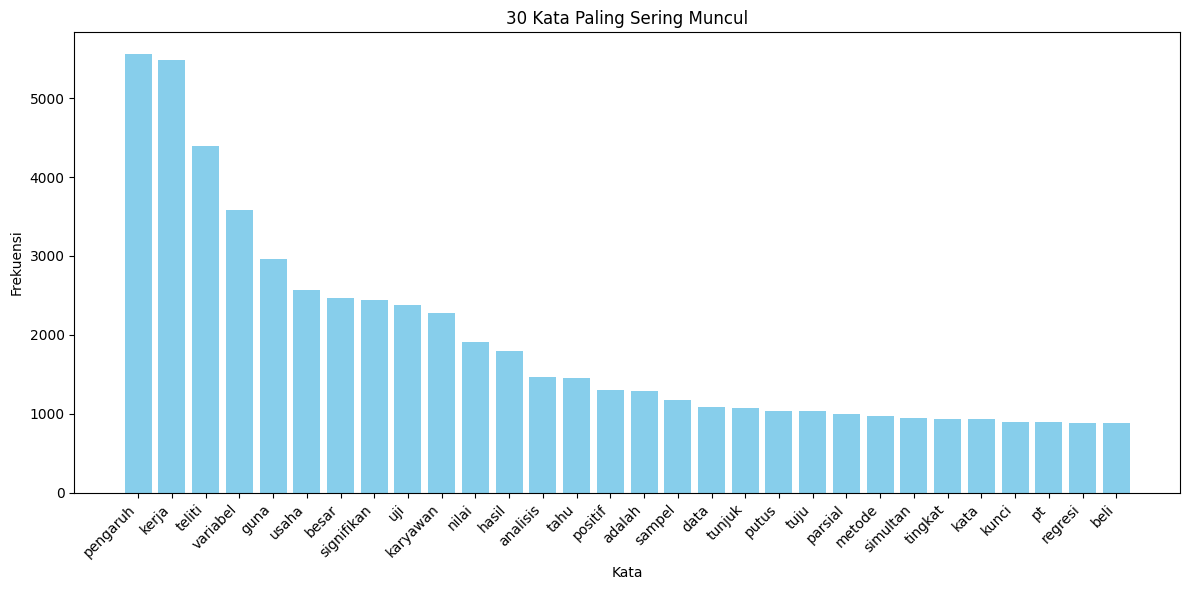

In [19]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Gabungkan semua token
all_tokens = [tok for tokens in abstrak_df['tokens'] for tok in tokens]

# Hitung frekuensi kata
word_freq = Counter(all_tokens)

# Jadi DataFrame terurut dari besar ke kecil
freq_df = pd.DataFrame(word_freq.most_common(), columns=['kata','frekuensi'])

# Tambahkan index ranking mulai dari 1
freq_df.index = range(1, len(freq_df)+1)
freq_df.index.name = 'rank'

# Simpan frekuensi kata ke CSV
freq_df.to_csv('/content/drive/MyDrive/PPW/frekuensi_kata.csv', index=True)
print("Frekuensi kata berhasil disimpan ke CSV!\n")

# Tampilkan 30 kata teratas
top_n = 30
print(freq_df.head(top_n))

# Visualisasi 30 kata teratas
top_words = freq_df.head(top_n)
plt.figure(figsize=(12,6))
plt.bar(top_words['kata'], top_words['frekuensi'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title(f"{top_n} Kata Paling Sering Muncul")
plt.tight_layout()
plt.show()
